# Dendrogram simplification study

Illustrates the single-linkage chaining pathology and how the
simplification step removes it.


In [2]:
from pathlib import Path

import numpy as np                                                                                                                                                                                                  
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, fcluster                                                                                                                                                            
from sklearn.datasets import load_digits                                                                                                                                                                            
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score                                                                                                                                       
                                                                                                                                                                                                                    
from mpc.bifiltration_processor import BifiltrationProcessor
from mpc.clustering_utils import ClusteringUtils                                                                                                                                                                    
from mpc.experiment_utils import align_hungarian
from mpc.filtration_builder import FiltrationBuilder                                                                                                                                                                
from mpc.pipeline import normalize_filtration, run_standard_baselines
                                                                                                                                                                                                                    
FIG = Path("figures")
FIG.mkdir(exist_ok=True)

In [4]:
rng = np.random.RandomState(42)
a = rng.uniform(0, 2 * np.pi, 200)
r = 3.0 + 0.3 * rng.randn(200)
ring = np.column_stack([r * np.cos(a), r * np.sin(a)])
out = 0.8 * rng.randn(30, 2)
X = np.vstack([ring, out])
y = np.r_[np.zeros(200, int), np.ones(30, int)]
N = len(X)

fb = FiltrationBuilder(X)
f1 = fb.get_filtration_from_scipy_dist("euclidean")
f2 = normalize_filtration(fb.get_filtration_from_density("gaussian", 0.6),
                          max(v for _, v in f1))
W1 = FiltrationBuilder.filtration_to_weight_matrix(f1, N)
W2 = FiltrationBuilder.filtration_to_weight_matrix(f2, N)
W = BifiltrationProcessor.combined_weight_matrix(W1, W2, normalize=False)
Z_raw = ClusteringUtils.linkage_from_weight_matrix(W)

In [6]:
sizes = [1, 2, 3, 5, 8, 12, 18, 25, 35, 50]
ari_sim, ari_pc = [], []
for m in sizes:
    ari_sim.append(adjusted_rand_score(y,
        ClusteringUtils.simplified_labels(Z_raw, n_clusters=2, min_size=m)))
    ari_pc.append(adjusted_rand_score(y,
        ClusteringUtils.persistence_cut(Z_raw, n_clusters=2, min_cluster_size=m)))

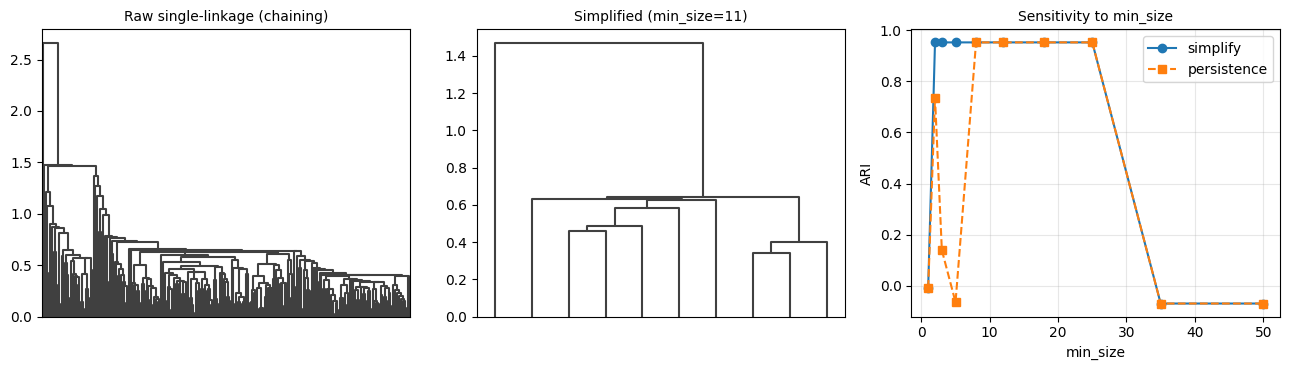

In [7]:
min_size = max(2, N // 20)
sim_Z, _ = ClusteringUtils.simplify_linkage(Z_raw, min_size=min_size)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
dendrogram(Z_raw, ax=axes[0], no_labels=True, color_threshold=0,
           above_threshold_color="0.25")
axes[0].set_title("Raw single-linkage (chaining)", fontsize=10)

dendrogram(sim_Z, ax=axes[1], no_labels=True, color_threshold=0,
           above_threshold_color="0.25")
axes[1].set_title(f"Simplified (min_size={min_size})", fontsize=10)

axes[2].plot(sizes, ari_sim, "o-", label="simplify")
axes[2].plot(sizes, ari_pc, "s--", label="persistence")
axes[2].set_xlabel("min_size"); axes[2].set_ylabel("ARI")
axes[2].set_title("Sensitivity to min_size", fontsize=10)
axes[2].grid(alpha=0.3); axes[2].legend()

fig.tight_layout()
fig.savefig(FIG / "simplification.png", dpi=150, bbox_inches="tight")
plt.show()

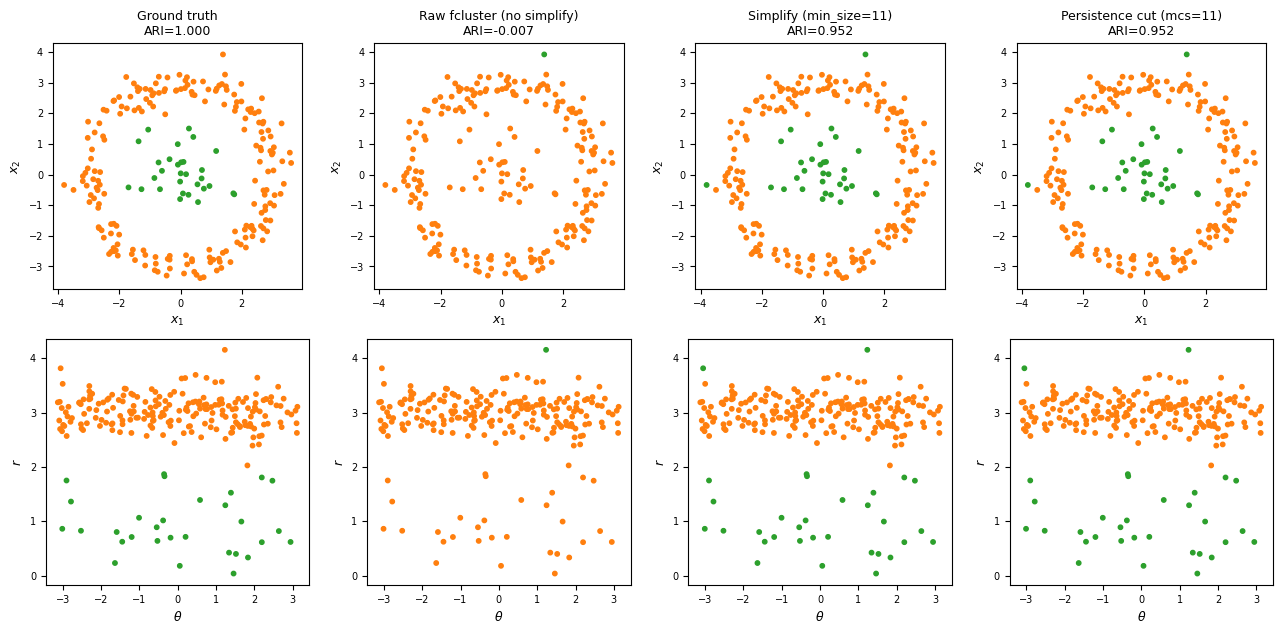

In [8]:
panels = [
    ("Ground truth", y),
    ("Raw fcluster (no simplify)",  fcluster(Z_raw, t=2, criterion="maxclust") - 1),
    (f"Simplify (min_size={min_size})",
     ClusteringUtils.simplified_labels(Z_raw, n_clusters=2, min_size=min_size)),
    (f"Persistence cut (mcs={min_size})",
     ClusteringUtils.persistence_cut(Z_raw, n_clusters=2, min_cluster_size=min_size)),
]
r_polar = np.sqrt(X[:, 0] ** 2 + X[:, 1] ** 2)
th_polar = np.arctan2(X[:, 1], X[:, 0])

fig, axes = plt.subplots(2, 4, figsize=(13, 6.4))
for col, (title, lab) in enumerate(panels):
    lab_aligned, _ = align_hungarian(lab, y)
    ari = adjusted_rand_score(y, lab)
    axes[0, col].scatter(X[:, 0], X[:, 1], c=lab_aligned, cmap="tab10",
                         s=10, vmin=0, vmax=9)
    axes[0, col].set_title(f"{title}\nARI={ari:.3f}", fontsize=9)
    axes[0, col].set_aspect("equal")
    axes[0, col].set_xlabel(r"$x_1$", fontsize=9)
    axes[0, col].set_ylabel(r"$x_2$", fontsize=9)
    axes[1, col].scatter(th_polar, r_polar, c=lab_aligned, cmap="tab10",
                         s=10, vmin=0, vmax=9)
    axes[1, col].set_xlabel(r"$\theta$", fontsize=9)
    axes[1, col].set_ylabel(r"$r$", fontsize=9)
    for ax in (axes[0, col], axes[1, col]):
        ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig(FIG / "simplification_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## Real, non-2D dataset: `Digits {0, 6, 9}`

300 random `sklearn` digits from classes 0/6/9, each `8×8` flattened to
`R^64` and `L2`-normalised. The filtration runs on cosine distance.


In [11]:
classes = (0, 6, 9)
X_all, y_all = load_digits(return_X_y=True)
mask = np.isin(y_all, classes)
rng = np.random.RandomState(0)
idx = rng.permutation(np.sum(mask))[:300]
X_raw = X_all[mask][idx]
y_true = np.searchsorted(classes, y_all[mask][idx])

X = X_raw / np.linalg.norm(X_raw, axis=1, keepdims=True).clip(1e-9)
N = len(X)
Z = ClusteringUtils.get_linkage_matrix(
    FiltrationBuilder(X).get_filtration_from_scipy_dist("cosine"), N,
)
ms = 20

results = dict(run_standard_baselines(X, 3))
results["Raw fcluster"] = fcluster(Z, t=3, criterion="maxclust") - 1
results[f"Simplify (ms={ms})"] = ClusteringUtils.simplified_labels(
    Z, n_clusters=3, min_size=ms,
)

scores = {
    name: (adjusted_rand_score(y_true, lab),
           normalized_mutual_info_score(y_true, lab))
    for name, lab in results.items()
}

/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


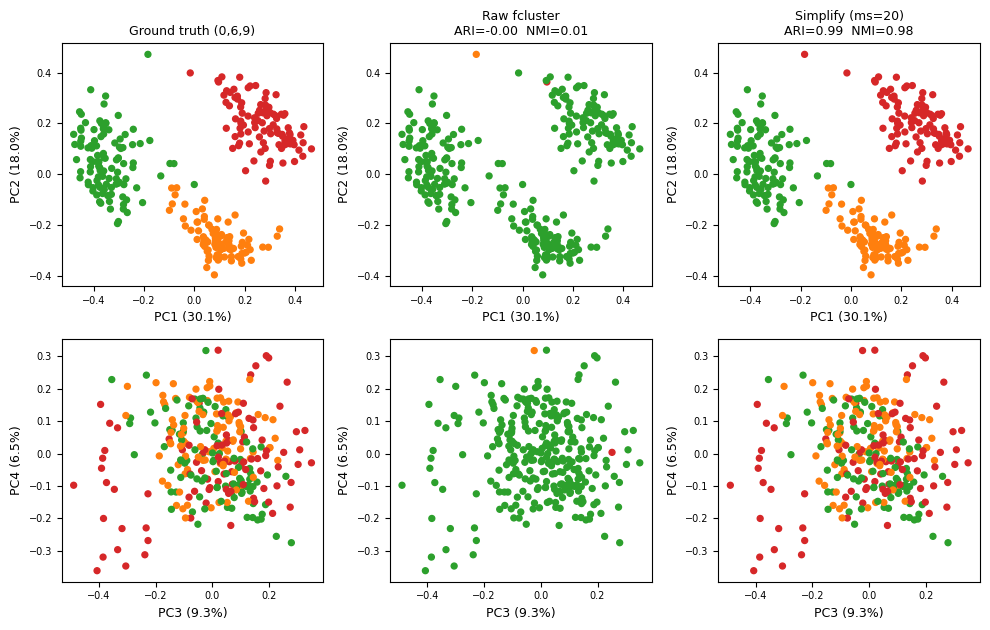

In [12]:
pca = PCA(n_components=4).fit(X)
Xv = pca.transform(X)
evr = pca.explained_variance_ratio_ * 100


def _title(name):
    ari, nmi = scores[name]
    return f"{name}\nARI={ari:.2f}  NMI={nmi:.2f}"


key_panels = [
    ("Ground truth (0,6,9)",   y_true),
    (_title("Raw fcluster"),   results["Raw fcluster"]),
    (_title(f"Simplify (ms={ms})"), results[f"Simplify (ms={ms})"]),
]
fig, axes = plt.subplots(2, 3, figsize=(10, 6.4))
for col, (title, lab) in enumerate(key_panels):
    lab_aligned, _ = align_hungarian(lab, y_true)
    axes[0, col].scatter(Xv[:, 0], Xv[:, 1], c=lab_aligned, cmap="tab10",
                         s=18, vmin=0, vmax=9)
    axes[0, col].set_title(title, fontsize=9)
    axes[0, col].set_xlabel(f"PC1 ({evr[0]:.1f}%)", fontsize=9)
    axes[0, col].set_ylabel(f"PC2 ({evr[1]:.1f}%)", fontsize=9)
    axes[1, col].scatter(Xv[:, 2], Xv[:, 3], c=lab_aligned, cmap="tab10",
                         s=18, vmin=0, vmax=9)
    axes[1, col].set_xlabel(f"PC3 ({evr[2]:.1f}%)", fontsize=9)
    axes[1, col].set_ylabel(f"PC4 ({evr[3]:.1f}%)", fontsize=9)
    for ax in (axes[0, col], axes[1, col]):
        ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig(FIG / "simplification_real.png", dpi=150, bbox_inches="tight")
plt.show()

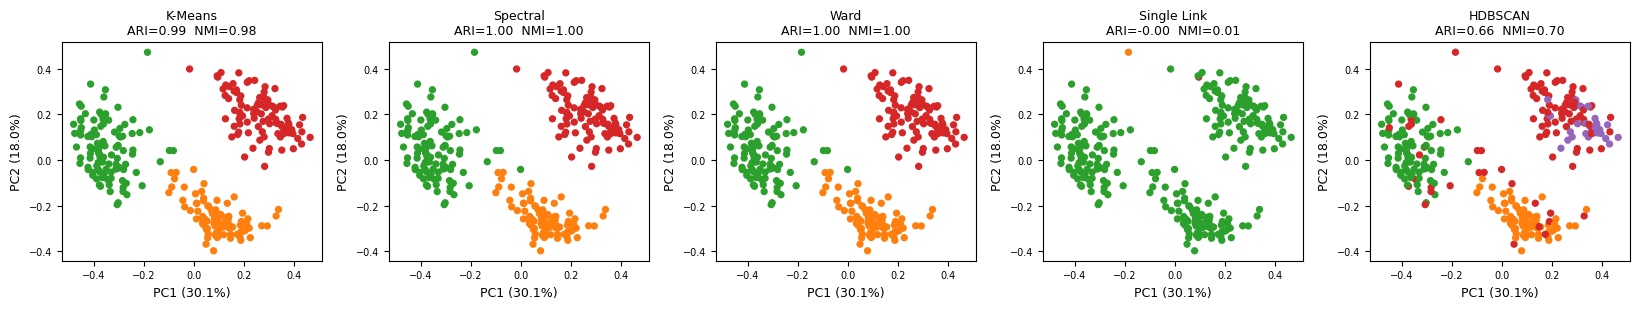

In [13]:
omit = {"Raw fcluster", f"Simplify (ms={ms})"}
baselines = [(n, l) for n, l in results.items() if n not in omit]

fig, axes = plt.subplots(1, len(baselines), figsize=(3.3 * len(baselines), 3.2))
for ax, (name, lab) in zip(axes, baselines):
    lab_aligned, _ = align_hungarian(lab, y_true)
    ax.scatter(Xv[:, 0], Xv[:, 1], c=lab_aligned, cmap="tab10",
               s=18, vmin=0, vmax=9)
    ari, nmi = scores[name]
    ax.set_title(f"{name}\nARI={ari:.2f}  NMI={nmi:.2f}", fontsize=9)
    ax.set_xlabel(f"PC1 ({evr[0]:.1f}%)", fontsize=9)
    ax.set_ylabel(f"PC2 ({evr[1]:.1f}%)", fontsize=9)
    ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig(FIG / "simplification_real_baselines.png", dpi=150, bbox_inches="tight")
plt.show()

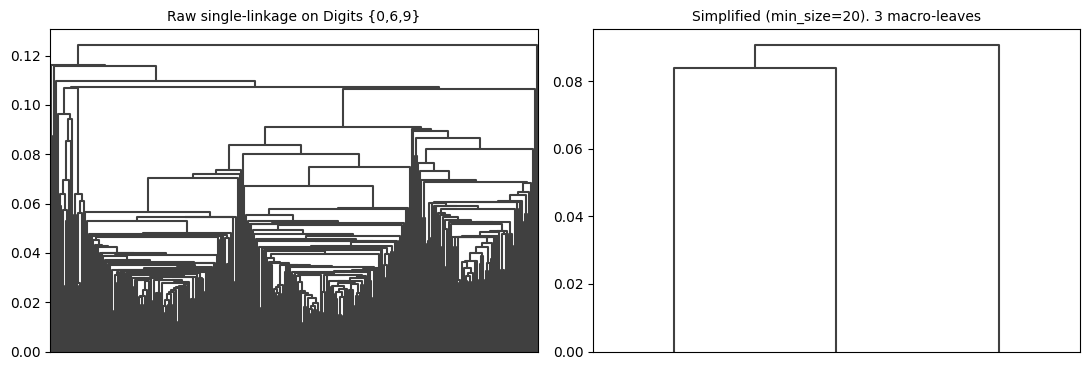

In [15]:
sim_Z_dig, leaves_dig = ClusteringUtils.simplify_linkage(Z, min_size=ms)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
dendrogram(Z, ax=axes[0], no_labels=True, color_threshold=0,
           above_threshold_color="0.25")
axes[0].set_title("Raw single-linkage on Digits {0,6,9}", fontsize=10)

dendrogram(sim_Z_dig, ax=axes[1], no_labels=True, color_threshold=0,
           above_threshold_color="0.25")
axes[1].set_title(
    f"Simplified (min_size={ms}). {len(leaves_dig)} macro-leaves",
    fontsize=10,
)
fig.tight_layout()
fig.savefig(FIG / "simplification_real_dendro.png", dpi=150, bbox_inches="tight")
plt.show()
